In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Spatial density function
def rho(x):
    R = 1.0  # Radius
    if abs(x) <= R:
        return 1.0
    else:
        return 0.1
        
def rejection_sampling_positions(number_samples):
    #number_samples = 1000 # Number of samples
    sampled_positions = []
    
    # Define the domain bounds
    x_min, x_max = -1.0, 1.0
    
    
    # Sample x uniformly from the domain 
    positions = np.random.uniform(x_min, x_max, number_samples)
    # Compute rho(x) in the domain D
    density_values = np.array([rho(x) for x in positions])
    p_max = np.max(density_values) # Maximum of rho(x)
    
    for i in range(len(density_values)):
        r = density_values[i] / p_max # Compute r(x) (rejection sampling)
        
        # Accept/reject based on r
        if np.random.uniform(0, 1) < r:
            sampled_positions.append(positions[i])
            
    num_samples = len(sampled_positions) # Number of samples
    return num_samples, sampled_positions

In [15]:
def u(x):
    # return 0.0
    delta = 5e-3  
    return delta * np.sin(2 * np.pi * x)
    
def T(x):
    return 1.0 + 0.001 * x  

def sample_velocities(sampled_positions):
    # Compute bulk velocity for sampled positions 2D
    bulk_velocities = np.array([u(x) for x in sampled_positions])
    #bulk_velocities = np.array([[0, 0] for x, y in sampled_positions]) 
    
    
    
    # Sample velocities for each position
    sampled_velocities = []
    for x, u_x in zip(sampled_positions, bulk_velocities):
        mean_velocity = [u_x]
        variance = T(x)
        velocity_sample = np.random.normal(mean_velocity, np.sqrt(variance))
        sampled_velocities.append(velocity_sample)
    
    #sampled_velocities = np.array(sampled_velocities)
    return sampled_velocities

In [34]:
import sympy as sp
import numpy as np
from sympy.functions.special.bsplines import bspline_basis


def generate_knot_vector(a, b, num_internal_knots, degree):
    
    # Generate clamped knot vector 
    
    # Interior knots uniformly
    interior_knots = np.linspace(a, b, num_internal_knots + 2)[1:-1].tolist()

    # Clamped knots at start and end
    start_knots = [a] * (degree + 1)
    end_knots = [b] * (degree + 1)
    
    # Combine boundary and interior knots
    knot_vector = tuple(start_knots + interior_knots + end_knots)
    #knot_vector = tuple(np.linspace(a, b, num_internal_knots))
    #print(knot_vector)
    return knot_vector

# symbolic variables
x = sp.symbols('x')
v = sp.symbols('v')

def generate_b_spline_basis(a, b, num_internal_knots, degree, symbol):
    
    # Create clamped knots (repeated degree + 1 times at endpoints)
    clamped_knots = generate_knot_vector(a, b, num_internal_knots, degree)
    print(f"number of clamped knots in variable {symbol} is: {len(clamped_knots)}")
    num_basis = len(clamped_knots) - degree - 1
    print(f"number of B-spline basis functions of degree {degree} in variable {symbol} is : {num_basis}")
    basis_functions = []
    
    for i in range(num_basis):
        basis = bspline_basis(degree, clamped_knots, i, symbol)
        basis_functions.append(basis)
    
    return basis_functions, clamped_knots

   
def compute_b_spline_integral(phi_i, phi_j, symbol, a_local, b_local):

    product = phi_i * phi_j
    integral = sp.integrate(product, (symbol, a_local, b_local))
    return integral.evalf()  # Convert to float

def compute_M1_M2(basis, knots, degree, symbol):

    n = len(basis)
    M = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            # Extract local knots for \phi_i and \phi_j
            support_i = (knots[i], knots[i + degree + 1])
            support_j = (knots[j], knots[j + degree + 1])
            # Calculate overlap interval
            overlap_start = max(support_i[0], support_j[0])
            overlap_end = min(support_i[1], support_j[1])
            
            if overlap_start >= overlap_end:
                M[i, j] = 0.0
            else:
                M[i, j] = compute_b_spline_integral(basis[i], basis[j], symbol, overlap_start, overlap_end)
    
    return M
    
def compute_C_hat(phi_basis, psi_basis, x_samples, v_samples):

    #Compute C_hat[k, l] = (1/N) \sum \phi_k(x_sample)\psi_l(v_sample).

    num_phi = len(phi_basis)
    num_psi = len(psi_basis)
    C_hat = np.zeros((num_phi, num_psi))
    
    # Lambdify converts SymPy's symbolic B-spline basis functions into numerical functions
    phi_funcs = [sp.lambdify(x, phi, 'numpy') for phi in phi_basis]
    psi_funcs = [sp.lambdify(v, psi, 'numpy') for psi in psi_basis]
    
    for k in range(num_phi):
        for l in range(num_psi):
            for x_i, v_i in zip(x_samples, v_samples):
                C_hat[k, l] += phi_funcs[k](x_i) * psi_funcs[l](v_i)
    
    return C_hat / len(x_samples)

# Parameters
x_a, x_b = -1, 1 # spatial domain
num_internal_knots_x = 16  # Interior knots on spatial domain (excludes clamped ends)
degree_x = 3 # degree of b-splines for spatial domain

v_a, v_b = -10, 10 # velocity domain
num_internal_knots_v = 16 # Interior knots on velocity domain (excludes clamped ends)
degree_v = 3 # degree of b-splines for velocity domain

number_samples = 1000


# Generate spatial and velocity basis
phi_basis_x, knots_x = generate_b_spline_basis(x_a, x_b, num_internal_knots_x, degree_x, x)
psi_basis_v, knots_v = generate_b_spline_basis(v_a, v_b, num_internal_knots_v, degree_v, v)

# Compute M1 (spaatial matrix)and M2 (velocity matrix) symbolically
M1 = compute_M1_M2(phi_basis_x, knots_x, degree_x, x)
M2 = compute_M1_M2(psi_basis_v, knots_v, degree_v, v)

# Sample data 
_, x_samples = rejection_sampling_positions(number_samples)
v_samples = sample_velocities(x_samples)

# x_samples = np.random.uniform(x_a, x_b, num_samples)
# v_samples = np.random.uniform(v_a, v_b, num_samples)

# Compute C_hat 
C_hat = compute_C_hat(phi_basis_x, psi_basis_v, x_samples, v_samples)

# Compute C
C = np.linalg.inv(M1).T @ C_hat @ np.linalg.inv(M2)
print(M1)
print(M2)
print(C_hat)
print(C)

number of clamped knots in variable x is: 24
number of B-spline basis functions of degree 3 in variable x is : 20
number of clamped knots in variable v is: 24
number of B-spline basis functions of degree 3 in variable v is : 20


/tmp/ipykernel_60407/621835322.py:85: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  C_hat[k, l] += phi_funcs[k](x_i) * psi_funcs[l](v_i)


[[1.68067224e-02 1.02941177e-02 2.17086807e-03 1.40056014e-04
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.02941177e-02 2.60504196e-02 1.83823534e-02 4.06162467e-03
  3.50139962e-05 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.17086807e-03 1.83823534e-02 3.84453783e-02 2.64239029e-02
  2.78944915e-03 2.33426715e-05 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.40056014e-04 4.06162467e-03 2.64239029e-02 5.63958918e-02
  2.7

Error Norm: 1.5793609780108915


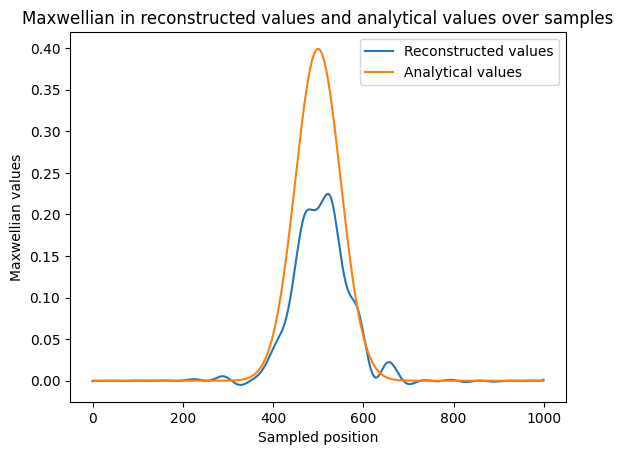

In [35]:
# Analytical Maxwellian function
def analytical_maxwellian(rho, u, T, ve):
    #d_v = len(ve)  # Dimensionality of velocity space
    d_v = 1
    return rho / ((2 * np.pi * T)**(d_v / 2)) * np.exp(-np.linalg.norm(ve - u)**2 / (2 * T))


# Create spatial grid
x_grid = np.linspace(-1, 1, 1000)
v_grid = np.linspace(-10, 10, 1000)


#Compute analytical Maxwellian values for comparison
# analytical_values = [
#     analytical_maxwellian(rho(x_i), u=[u(x_i)], T=T(x_i), ve=velocity)
#     for x_i, velocity in zip(x_grid, sample_velocities(x_grid))
# ]
analytical_values = [
    analytical_maxwellian(rho(x_i), u=[u(x_i)], T=T(x_i), ve=velocity)
    for x_i, velocity in zip(x_grid, v_grid)
]
# Reconstructed Maxwellian function
def reconstructed_maxwellian(phi_basis_x, psi_basis_v, x_i, v_j, C):
    
    num_phi = len(phi_basis_x)
    num_psi = len(psi_basis_v)
    result = 0

    # Lambdify converts SymPy's symbolic B-spline basis functions into numerical functions
    phi_funcs = [sp.lambdify(x, phi, 'numpy') for phi in phi_basis_x]
    psi_funcs = [sp.lambdify(v, psi, 'numpy') for psi in psi_basis_v]
    
    for i in range((num_phi)):
        for j in range((num_psi)):
            result += (
                    C[i, j] *
                    phi_funcs[i](x_i) * 
                    psi_funcs[j](v_j) 
                        )
    return result

# Reconstructed values for comparison
# reconstructed_values =  [reconstructed_maxwellian(phi_basis_x, psi_basis_v, x_i, v_j, C) for x_i, v_j in zip(x_grid, sample_velocities(x_grid))]
reconstructed_values =  [reconstructed_maxwellian(phi_basis_x, psi_basis_v, x_i, v_j, C) for x_i, v_j in zip(x_grid, v_grid)]


# Compute the error norm \\M_true - M_reconstructed\\_2
analytical_array = np.array(analytical_values)
reconstructed_array = np.array(reconstructed_values)

error_norm = np.linalg.norm(analytical_array - reconstructed_array)
print(f"Error Norm: {error_norm:}")
##################################
# Plot the error reconstructed_values and analytical values of Maxwellian function

fig, ax = plt.subplots()

ax.plot(reconstructed_values, label='Reconstructed values')
ax.plot(analytical_values, label='Analytical values')
ax.set_xlabel('Sampled position')
ax.set_ylabel('Maxwellian values')
ax.set_title('Maxwellian in reconstructed values and analytical values over samples')
ax.legend()
plt.show()

In [9]:
import numpy as np
from scipy.interpolate import BSpline
from scipy.integrate import quad

# Generate a clamped uniform knot vector, num_knots = num_basis_functions + p  +1 
def generate_knot_vector(a, b, num_knots, degree):
    
    # # interior knots uniformly
    # interior_knots = np.linspace(a, b, num_knots - 2 * (degree +1) )
    # # Clamped boundary knots 
    # start_knots = [a] * (degree + 1)
    # end_knots = [b] * (degree + 1)
    
    # # Combine boundary and interior knots
    # knot_vector = np.concatenate([start_knots, interior_knots, end_knots])
    knot_vector = np.linspace(a, b, num_knots)
    return knot_vector
    
# Generate B-spline basis functions with clamped knots    
def generate_b_spline_basis(a, b, num_knots, degree):

    # Create clamped knots (repeated degree + 1 times at endpoints)
    clamped_knots = generate_knot_vector(a, b, num_knots, degree)
    basis_functions = []
    local_knots_list = []

    # Generate each basis function
    for i in range(len(clamped_knots) - degree - 1):
        local_knots = clamped_knots[i:i+degree+2]
        local_knots_list.append(local_knots)
        basis = BSpline.basis_element(local_knots, extrapolate=False)  
        basis_functions.append(basis)
    
    return basis_functions, clamped_knots, local_knots_list 
    
# Compute \int \phi_i(x)\phi_j(x)dx over their overlapping support
def compute_overlap_integral_b_splines(phi, local_knots_list, i, j):

    # Extract local knots for φ_i and φ_j
    support_i = local_knots_list[i]
    support_j = local_knots_list[j]
    
    # Calculate overlap interval
    overlap_start = max(support_i[0], support_j[0])
    overlap_end = min(support_i[-1], support_j[-1])

    if overlap_start >= overlap_end:
        return 0.0 # No overlap
    
    # Integrate 
    result, _ = quad(
        lambda x: phi[i](x) * phi[j](x),
        overlap_start, overlap_end,
        epsabs=1e-10, epsrel=1e-6
    )
    return result

# Compute matrices M1, M2, and coefficients C_hat
def compute_matrices_and_coefficients(x_min, x_max, v_min, v_max, num_x_knots, num_v_knots, degree_x, degree_v, number_samples):
    num_phi = num_x_knots - degree_x - 1
    num_psi = num_v_knots - degree_v - 1

    # Initialize matrices and coefficient matrix
    M1 = np.zeros((num_phi, num_phi))  # Spatial matrix
    M2 = np.zeros((num_psi, num_psi))  # Velocity matrix
    C_hat = np.zeros((num_phi, num_psi))  # Coefficient matrix

    # Compute Spatial matrix M1
    phi_x, clamped_x_knots, x_local_knots_list = generate_b_spline_basis(x_min, x_max, num_x_knots, degree_x)
    # print(clamped_x_knots)
    # print(x_local_knots_list)
    for i in range(num_phi):
        for k in range(num_phi):
            M1[i, k] = compute_overlap_integral_b_splines(phi_x, x_local_knots_list, i, k)

    # # Compute velocity matrix M2
    psi_v, clamped_v_knots, v_local_knots_list = generate_b_spline_basis(v_min, v_max, num_v_knots, degree_v)
    for j in range(num_psi):
        for l in range(num_psi):
            M2[j, l] = compute_overlap_integral_b_splines(psi_v, v_local_knots_list, j, l)

    # Compute C_hat E_p[\phi_i(x) \kron \psi_j(v)] over sampled positions and sampled velocity 
    num_samples, sampled_positions = rejection_sampling_positions(number_samples)
    sampled_velocities = sample_velocities(sampled_positions)
    # print(num_samples)
    # print(len(sampled_positions))
    # print(len(sampled_velocities))
    # for x_i, v_i in zip(sampled_positions, sampled_velocities):
    #     # Evaluate all φ_k at x_i
    #     phi_vals = np.array([phi(x_i) for phi in phi_x])
    #     # Evaluate all ψ_l at v_i
    #     psi_vals = np.array([psi(v_i) for psi in psi_v])
    #     # Accumulate outer product
    #     C_hat += np.outer(phi_vals, psi_vals)
    for k in range(num_phi):
        for l in range(num_psi):
            for x_sp, velocity in zip(sampled_positions, sampled_velocities):
                # print(phi_x[k])
                # print(phi_x[k](x_sp))
                C_hat[k, l] += (
                            phi_x[k](x_sp) * 
                            psi_v[l](velocity)
                       )
    C_hat /= num_samples
    
    C = np.linalg.pinv(M1).T @ C_hat @ np.linalg.pinv(M2)
    return M1, M2, C_hat, C



number_samples = 1000

x_a, x_b = -1, 1 # spatial domain
num_x_knots = 9  # number of knots on spatial domain
degree_x = 2  # degree of b-splines for spatial domain
num_clamped_knots_x = num_x_knots 

v_a, v_b = -10, 10 # velocity domain 
num_v_knots = 20  # number of knots on velocity domain
degree_v = 3  # degree of b-splines for velocity domain
num_clamped_knots_v = num_v_knots 

M1, M2, C_hat, C = compute_matrices_and_coefficients(x_a, x_b, v_a, v_b, num_x_knots, num_v_knots, degree_x, degree_v, number_samples)
print(C_hat)
# print(f"number of clamped knots on spatial and velocity domain are: {num_clamped_knots_x, num_clamped_knots_x}")
# print(f"number of spatial and velocity basis functions are: {len(phi)}")

# # Generate basis functions and their knot lists
# phi, clamped_knots, knots_list = generate_b_spline_basis(a, b, num_knots, degree)
# print(f"number of clamped knots is: {num_clamped_knots}")
# print(f"number of basis functions is: {len(phi)}")

# # Compute integral of φ₁(x) with itself
# integral = compute_overlap_integral(phi, knots_list , 1, 1)



/tmp/ipykernel_60407/1058770550.py:100: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  C_hat[k, l] += (


[[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]]
